In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('DataSet\\cardio_train.csv', sep=';')


In [ ]:

# from google.colab import drive  # type: ignore
# drive.mount('/content/drive')

# df = pd.read_csv('/content/drive/MyDrive/Project/cardio_train.csv' , sep=';')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [4]:
df.tail()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1
69999,99999,20540,1,170,72.0,120,80,2,1,0,0,1,0


In [5]:
df.isnull().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [8]:
df["age_years"] = df["age"] / 365

In [9]:
df['age_years'] = df['age_years'].astype(int)
df['age_years'].value_counts()

age_years
55    3927
53    3868
57    3686
56    3607
54    3605
59    3576
49    3417
58    3409
51    3368
52    3279
50    3216
60    3200
63    2736
61    2728
62    2199
47    2197
64    2187
45    2087
43    2031
41    1903
48    1811
39    1780
46    1625
40    1622
44    1514
42    1418
29       3
30       1
Name: count, dtype: int64

In [10]:
# BMI (Body Mass Index) = weight / height²

df['BMI'] = df['weight'] / ((df['height']/100) ** 2)
df['BMI'] = df['BMI'].round(2)
df['BMI']

0        21.97
1        34.93
2        23.51
3        28.71
4        23.01
         ...  
69995    26.93
69996    50.47
69997    31.35
69998    27.10
69999    24.91
Name: BMI, Length: 70000, dtype: float64

In [11]:
# Pulse Pressure = ap_hi - ap_lo

df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']
df['pulse_pressure'] = df['pulse_pressure'].round(2)
df['pulse_pressure']

0        30
1        50
2        60
3        50
4        40
         ..
69995    40
69996    50
69997    90
69998    55
69999    40
Name: pulse_pressure, Length: 70000, dtype: int64

In [12]:
df["hypertension"] = (
    (df["ap_hi"] >= 140) |
    (df["ap_lo"] >= 90)
).astype(int)

# 140/90 or above avu hoi etle k te ne high blood pressure che etle ahiya tene apde 1 value api didhi

df["hypertension"].value_counts()

hypertension
0    45295
1    24705
Name: count, dtype: int64

In [13]:
# Obesity etle k body mass index (BMI) 30 ke upar hoi to te ne obesity kevaay 
# BMI>=30 hoi tya value 1 else 0

df["obesity"] = (df["BMI"] >= 30).astype(int) 
df["obesity"].value_counts()

obesity
0    51475
1    18525
Name: count, dtype: int64

In [14]:
# colesterol ma 3 value hatu 1 means normal , 2 means above normal and 3 means well above normal. So, apde ahiya 1 ne 0 and baki ne 1 value api didhi.
# ahiya apde jeni value 1 karta vadhare hoi ne tene high colesterol kai didhu 

df["high_cholesterol"] = (df["cholesterol"] > 1).astype(int)
df["high_cholesterol"].value_counts()

high_cholesterol
0    52385
1    17615
Name: count, dtype: int64

In [15]:
# same glucose mate

df["high_glucose"] = (df["gluc"] > 1).astype(int)
df["high_glucose"].value_counts()

high_glucose
0    59479
1    10521
Name: count, dtype: int64

In [16]:
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,BMI,pulse_pressure,hypertension,obesity,high_cholesterol,high_glucose
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50,21.97,30,0,0,0,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55,34.93,50,1,1,1,0
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51,23.51,60,0,0,1,0
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48,28.71,50,1,0,0,0
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47,23.01,40,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0,52,26.93,40,0,0,0,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1,61,50.47,50,1,1,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1,52,31.35,90,1,1,1,0
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1,61,27.10,55,0,0,0,1


In [17]:
# import matplotlib.pyplot as plt

# numerical_cols = ["age_years", "height", "weight", "ap_hi", "ap_lo"]

# df[numerical_cols].hist(figsize=(15,8), bins=30)
# plt.suptitle("Distribution of Numerical Features")
# plt.show()

In [18]:
# import seaborn as sns

# plt.figure(figsize=(15,8))

# for i, col in enumerate(numerical_cols):
#     plt.subplot(2,3,i+1)
#     sns.boxplot(y=df[col])
#     plt.title(col)

# plt.tight_layout()
# plt.show()

In [19]:
# categorical_cols = [
#     "gender",
#     "cholesterol",
#     "gluc",
#     "smoke",
#     "alco",
#     "active",
#     "cardio"
# ]

# plt.figure(figsize=(15,10))

# for i, col in enumerate(categorical_cols):
#     plt.subplot(3,3,i+1)
#     sns.countplot(x=col, data=df)
#     plt.title(col)

# plt.tight_layout()
# plt.show()

In [20]:
# plt.figure(figsize=(12,10))

# sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

# plt.title("Correlation Heatmap")
# plt.show()

# # This tells you:

# # Which features are related?
# # Which features have the strongest relationship with cardio?
# # Which features are highly correlated with each other?

In [21]:
# selected = ["age", "height", "weight", "ap_hi", "ap_lo", "cardio"]

# sns.pairplot(df[selected], hue="cardio")
# plt.show()

In [22]:
# sns.boxplot(x="cardio", y="age", data=df)
# plt.show()

In [23]:
# sns.boxplot(x="cardio", y="weight", data=df)
# plt.show()

In [24]:
# sns.boxplot(x="cardio", y="ap_hi", data=df)
# plt.show()

In [25]:
# sns.countplot(x="cholesterol", hue="cardio", data=df)
# plt.show()

In [26]:
df.shape

(70000, 20)

In [27]:
# here we remove the outliers from the dataset 

# Height
df = df[(df["height"] >= 100) & (df["height"] <= 220)] 

# Weight
df = df[(df["weight"] >= 30) & (df["weight"] <= 250)]

# Blood pressure
df = df[
    (df["ap_hi"] >= 70) &
    (df["ap_hi"] <= 250) &
    (df["ap_lo"] >= 40) &
    (df["ap_lo"] <= 150)
]

# Systolic should be greater than diastolic
df = df[df["ap_hi"] > df["ap_lo"]]

In [28]:
df.shape

(68633, 20)

In [29]:
print(df.shape)

# print(df["height"].describe())
# print(df["weight"].describe())
# print(df["ap_hi"].describe())
print(df["ap_lo"].describe())

(68633, 20)
count    68633.000000
mean        81.301721
std          9.422616
min         40.000000
25%         80.000000
50%         80.000000
75%         90.000000
max        150.000000
Name: ap_lo, dtype: float64


In [30]:
# sns.boxplot(x="cardio", y="age_years", data=df)

In [31]:
# sns.boxplot(x="cardio", y="BMI", data=df)

In [32]:
# sns.boxplot(x="cardio", y="ap_hi", data=df)

In [33]:
# sns.countplot(x="cholesterol", hue="cardio", data=df)

In [34]:
# sns.countplot(x="gluc", hue="cardio", data=df)

In [35]:
# sns.countplot(x="smoke", hue="cardio", data=df)

In [36]:
# sns.countplot(x="alco", hue="cardio", data=df)

In [37]:
# sns.countplot(x="active", hue="cardio", data=df)

Shape of dataset: (68633, 20)

Columns:
['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'age_years', 'BMI', 'pulse_pressure', 'hypertension', 'obesity', 'high_cholesterol', 'high_glucose']

Target distribution:
cardio
0    34679
1    33954
Name: count, dtype: int64

Target percentage:
cardio
0    50.528172
1    49.471828
Name: proportion, dtype: float64

X shape: (68633, 14)
y shape: (68633,)

Training data: (54906, 14)
Testing data : (13727, 14)

BASELINE LOGISTIC REGRESSION
Accuracy  : 0.7306
Precision : 0.7662
Recall    : 0.6554
F1 Score  : 0.7065
ROC-AUC   : 0.7984

ONE-HOT ENCODED LOGISTIC REGRESSION
Accuracy  : 0.7310
Precision : 0.7678
Recall    : 0.6542
F1 Score  : 0.7065
ROC-AUC   : 0.7991

Classification Report:
                           precision    recall  f1-score   support

No Cardiovascular Disease       0.70      0.81      0.75      6936
   Cardiovascular Disease       0.77      0.65      0.71   

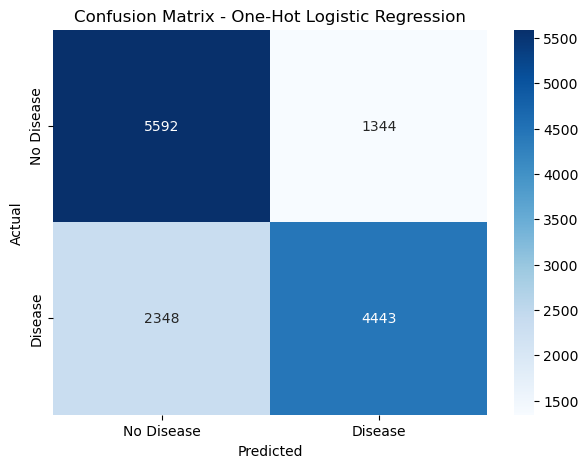


MODEL COMPARISON
                       Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
Baseline Logistic Regression    0.7306     0.7662  0.6554    0.7065   0.7984
 One-Hot Logistic Regression    0.7310     0.7678  0.6542    0.7065   0.7991


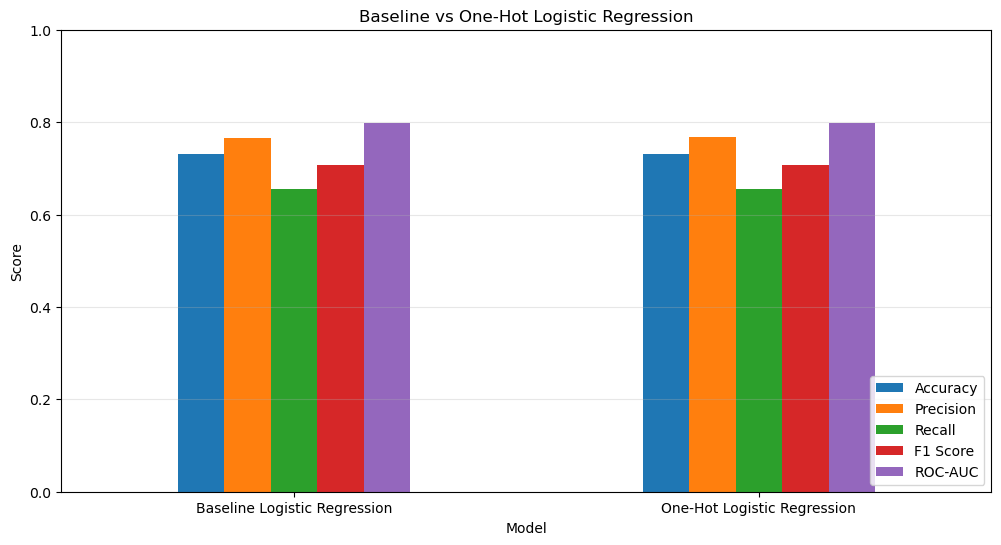


5-FOLD CROSS VALIDATION
ACCURACY  : 0.7292 +/- 0.0032
PRECISION : 0.7662 +/- 0.0044
RECALL    : 0.6514 +/- 0.0056
F1        : 0.7041 +/- 0.0039
ROC_AUC   : 0.7937 +/- 0.0047

HYPERPARAMETER TUNING
Best C: 100
Best CV ROC-AUC: 0.7923

TUNED LOGISTIC REGRESSION
Accuracy  : 0.7310
Precision : 0.7678
Recall    : 0.6542
F1 Score  : 0.7065
ROC-AUC   : 0.7991

Final Classification Report:
                           precision    recall  f1-score   support

No Cardiovascular Disease       0.70      0.81      0.75      6936
   Cardiovascular Disease       0.77      0.65      0.71      6791

                 accuracy                           0.73     13727
                macro avg       0.74      0.73      0.73     13727
             weighted avg       0.74      0.73      0.73     13727



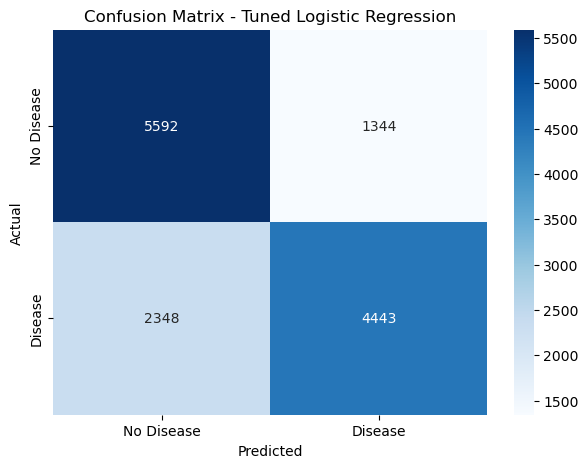

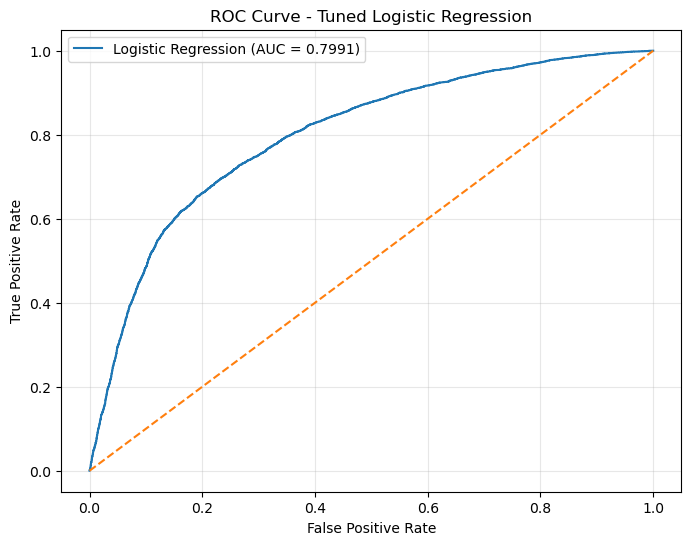


FINAL EXPERIMENT COMPARISON
                            Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
                 Current Baseline    0.7306     0.7662  0.6554    0.7065   0.7984
      One-Hot Logistic Regression    0.7310     0.7678  0.6542    0.7065   0.7991
Tuned One-Hot Logistic Regression    0.7310     0.7678  0.6542    0.7065   0.7991

IMPROVEMENT
Accuracy improvement : +0.04%
ROC-AUC improvement  : +0.07%


In [38]:
# ============================================================
# EXPERIMENT 1
# IMPROVING LOGISTIC REGRESSION
# Cardiovascular Disease Prediction
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)


# ============================================================
# 2. CHECK CURRENT DATA
# ============================================================

print("Shape of dataset:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nTarget distribution:")
print(df["cardio"].value_counts())

print("\nTarget percentage:")
print(df["cardio"].value_counts(normalize=True) * 100)


# ============================================================
# 3. SELECT FEATURES
# ============================================================

# These are the features from your current engineered dataset.

features = [
    "age_years",
    "gender",
    "height",
    "weight",
    "ap_hi",
    "ap_lo",
    "cholesterol",
    "gluc",
    "smoke",
    "alco",
    "active",
    "BMI",
    "pulse_pressure",
    "hypertension"
]

target = "cardio"


# Make sure all required columns exist
missing_columns = [col for col in features + [target] if col not in df.columns]

if len(missing_columns) > 0:
    print("\nMissing columns:")
    print(missing_columns)
    raise ValueError("Some required columns are missing from df.")


X = df[features].copy()
y = df[target].copy()


print("\nX shape:", X.shape)
print("y shape:", y.shape)


# ============================================================
# 4. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print("\nTraining data:", X_train.shape)
print("Testing data :", X_test.shape)


# ============================================================
# 5. DEFINE CATEGORICAL AND NUMERICAL FEATURES
# ============================================================

# These variables represent categories.
categorical_features = [
    "gender",
    "cholesterol",
    "gluc"
]


# These variables are numerical.
numerical_features = [
    "age_years",
    "height",
    "weight",
    "ap_hi",
    "ap_lo",
    "smoke",
    "alco",
    "active",
    "BMI",
    "pulse_pressure",
    "hypertension"
]


# ============================================================
# 6. BASELINE MODEL
# ============================================================

# This model represents the simple Logistic Regression approach.
# Categorical values are still treated as numerical values.

baseline_scaler = StandardScaler()

X_train_baseline = baseline_scaler.fit_transform(X_train)
X_test_baseline = baseline_scaler.transform(X_test)


baseline_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

baseline_model.fit(
    X_train_baseline,
    y_train
)


# Predictions
y_pred_baseline = baseline_model.predict(X_test_baseline)

# Probabilities for ROC-AUC
y_prob_baseline = baseline_model.predict_proba(X_test_baseline)[:, 1]


# ============================================================
# 7. BASELINE METRICS
# ============================================================

baseline_accuracy = accuracy_score(
    y_test,
    y_pred_baseline
)

baseline_precision = precision_score(
    y_test,
    y_pred_baseline
)

baseline_recall = recall_score(
    y_test,
    y_pred_baseline
)

baseline_f1 = f1_score(
    y_test,
    y_pred_baseline
)

baseline_auc = roc_auc_score(
    y_test,
    y_prob_baseline
)


print("\n" + "=" * 60)
print("BASELINE LOGISTIC REGRESSION")
print("=" * 60)

print(f"Accuracy  : {baseline_accuracy:.4f}")
print(f"Precision : {baseline_precision:.4f}")
print(f"Recall    : {baseline_recall:.4f}")
print(f"F1 Score  : {baseline_f1:.4f}")
print(f"ROC-AUC   : {baseline_auc:.4f}")


# ============================================================
# 8. ONE-HOT ENCODING + SCALING
# ============================================================

# OneHotEncoder converts:
#
# cholesterol = 1,2,3
#
# into separate columns:
#
# cholesterol_1
# cholesterol_2
# cholesterol_3

preprocessor = ColumnTransformer(
    transformers=[
        
        # Numerical features
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        
        # Categorical features
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)


# ============================================================
# 9. LOGISTIC REGRESSION WITH ONE-HOT ENCODING
# ============================================================

onehot_lr = Pipeline(
    steps=[
        
        (
            "preprocessor",
            preprocessor
        ),
        
        (
            "model",
            LogisticRegression(
                random_state=42,
                max_iter=1000
            )
        )
    ]
)


# Train
onehot_lr.fit(
    X_train,
    y_train
)


# Predictions
y_pred_onehot = onehot_lr.predict(X_test)

y_prob_onehot = onehot_lr.predict_proba(X_test)[:, 1]


# ============================================================
# 10. ONE-HOT MODEL METRICS
# ============================================================

onehot_accuracy = accuracy_score(
    y_test,
    y_pred_onehot
)

onehot_precision = precision_score(
    y_test,
    y_pred_onehot
)

onehot_recall = recall_score(
    y_test,
    y_pred_onehot
)

onehot_f1 = f1_score(
    y_test,
    y_pred_onehot
)

onehot_auc = roc_auc_score(
    y_test,
    y_prob_onehot
)


print("\n" + "=" * 60)
print("ONE-HOT ENCODED LOGISTIC REGRESSION")
print("=" * 60)

print(f"Accuracy  : {onehot_accuracy:.4f}")
print(f"Precision : {onehot_precision:.4f}")
print(f"Recall    : {onehot_recall:.4f}")
print(f"F1 Score  : {onehot_f1:.4f}")
print(f"ROC-AUC   : {onehot_auc:.4f}")


# ============================================================
# 11. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_onehot,
        target_names=[
            "No Cardiovascular Disease",
            "Cardiovascular Disease"
        ]
    )
)


# ============================================================
# 12. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred_onehot
)


plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "No Disease",
        "Disease"
    ],
    yticklabels=[
        "No Disease",
        "Disease"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - One-Hot Logistic Regression")

plt.show()


# ============================================================
# 13. COMPARE BASELINE VS ONE-HOT
# ============================================================

comparison = pd.DataFrame({

    "Model": [
        "Baseline Logistic Regression",
        "One-Hot Logistic Regression"
    ],

    "Accuracy": [
        baseline_accuracy,
        onehot_accuracy
    ],

    "Precision": [
        baseline_precision,
        onehot_precision
    ],

    "Recall": [
        baseline_recall,
        onehot_recall
    ],

    "F1 Score": [
        baseline_f1,
        onehot_f1
    ],

    "ROC-AUC": [
        baseline_auc,
        onehot_auc
    ]
})


print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

print(
    comparison.round(4).to_string(index=False)
)


# ============================================================
# 14. VISUAL COMPARISON
# ============================================================

comparison_plot = comparison.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Baseline vs One-Hot Logistic Regression")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(
    rotation=0
)

plt.legend(
    loc="lower right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()


# ============================================================
# 15. 5-FOLD CROSS VALIDATION
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}


cv_results = cross_validate(
    onehot_lr,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)


print("\n" + "=" * 60)
print("5-FOLD CROSS VALIDATION")
print("=" * 60)


for metric in scoring.keys():

    scores = cv_results[
        "test_" + metric
    ]

    print(
        f"{metric.upper():10s}: "
        f"{scores.mean():.4f} "
        f"+/- {scores.std():.4f}"
    )


# ============================================================
# 16. HYPERPARAMETER TUNING
# ============================================================

# C controls the strength of regularization.
#
# Small C  -> stronger regularization
# Large C  -> weaker regularization

param_grid = {

    "model__C": [
        0.001,
        0.01,
        0.1,
        1,
        10,
        100
    ]

}


grid_search = GridSearchCV(
    estimator=onehot_lr,
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    return_train_score=True
)


grid_search.fit(
    X_train,
    y_train
)


# ============================================================
# 17. BEST PARAMETERS
# ============================================================

print("\n" + "=" * 60)
print("HYPERPARAMETER TUNING")
print("=" * 60)

print(
    "Best C:",
    grid_search.best_params_["model__C"]
)

print(
    "Best CV ROC-AUC:",
    round(
        grid_search.best_score_,
        4
    )
)


# ============================================================
# 18. BEST MODEL ON TEST DATA
# ============================================================

best_lr = grid_search.best_estimator_


y_pred_best = best_lr.predict(
    X_test
)

y_prob_best = best_lr.predict_proba(
    X_test
)[:, 1]


# ============================================================
# 19. BEST MODEL METRICS
# ============================================================

best_accuracy = accuracy_score(
    y_test,
    y_pred_best
)

best_precision = precision_score(
    y_test,
    y_pred_best
)

best_recall = recall_score(
    y_test,
    y_pred_best
)

best_f1 = f1_score(
    y_test,
    y_pred_best
)

best_auc = roc_auc_score(
    y_test,
    y_prob_best
)


print("\n" + "=" * 60)
print("TUNED LOGISTIC REGRESSION")
print("=" * 60)

print(f"Accuracy  : {best_accuracy:.4f}")
print(f"Precision : {best_precision:.4f}")
print(f"Recall    : {best_recall:.4f}")
print(f"F1 Score  : {best_f1:.4f}")
print(f"ROC-AUC   : {best_auc:.4f}")


# ============================================================
# 20. FINAL CLASSIFICATION REPORT
# ============================================================

print("\nFinal Classification Report:")

print(
    classification_report(
        y_test,
        y_pred_best,
        target_names=[
            "No Cardiovascular Disease",
            "Cardiovascular Disease"
        ]
    )
)


# ============================================================
# 21. FINAL CONFUSION MATRIX
# ============================================================

cm_best = confusion_matrix(
    y_test,
    y_pred_best
)


plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_best,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "No Disease",
        "Disease"
    ],
    yticklabels=[
        "No Disease",
        "Disease"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "Confusion Matrix - Tuned Logistic Regression"
)

plt.show()


# ============================================================
# 22. ROC CURVE
# ============================================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_best
)


plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {best_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve - Tuned Logistic Regression"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()


# ============================================================
# 23. FINAL MODEL COMPARISON
# ============================================================

final_comparison = pd.DataFrame({

    "Model": [
        "Current Baseline",
        "One-Hot Logistic Regression",
        "Tuned One-Hot Logistic Regression"
    ],

    "Accuracy": [
        baseline_accuracy,
        onehot_accuracy,
        best_accuracy
    ],

    "Precision": [
        baseline_precision,
        onehot_precision,
        best_precision
    ],

    "Recall": [
        baseline_recall,
        onehot_recall,
        best_recall
    ],

    "F1 Score": [
        baseline_f1,
        onehot_f1,
        best_f1
    ],

    "ROC-AUC": [
        baseline_auc,
        onehot_auc,
        best_auc
    ]
})


print("\n" + "=" * 70)
print("FINAL EXPERIMENT COMPARISON")
print("=" * 70)

print(
    final_comparison.round(4).to_string(index=False)
)


# ============================================================
# 24. IMPROVEMENT FROM BASELINE
# ============================================================

accuracy_improvement = (
    best_accuracy - baseline_accuracy
) * 100


auc_improvement = (
    best_auc - baseline_auc
) * 100


print("\n" + "=" * 60)
print("IMPROVEMENT")
print("=" * 60)

print(
    f"Accuracy improvement : "
    f"{accuracy_improvement:+.2f}%"
)

print(
    f"ROC-AUC improvement  : "
    f"{auc_improvement:+.2f}%"
)

RANDOM FOREST RESULTS
Accuracy  : 0.7155
Precision : 0.7170
Recall    : 0.7021
F1 Score  : 0.7095
ROC-AUC   : 0.7726

Classification Report:
                           precision    recall  f1-score   support

No Cardiovascular Disease       0.71      0.73      0.72      6936
   Cardiovascular Disease       0.72      0.70      0.71      6791

                 accuracy                           0.72     13727
                macro avg       0.72      0.72      0.72     13727
             weighted avg       0.72      0.72      0.72     13727



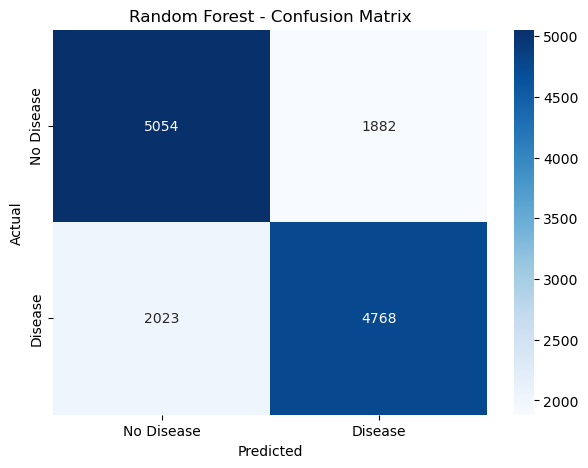

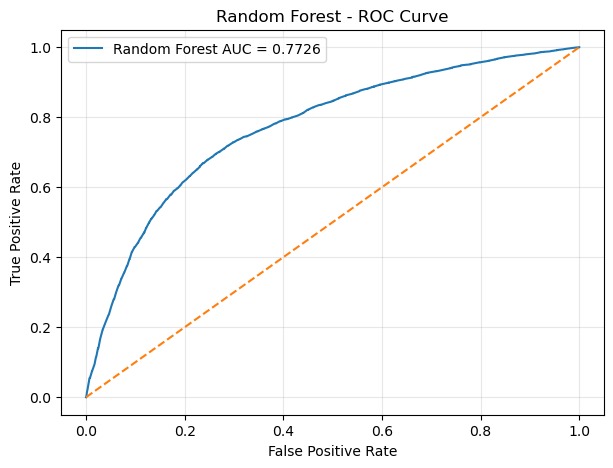


Feature Importance:
       Feature  Importance
           BMI    0.187910
     age_years    0.158648
        weight    0.140447
        height    0.134677
         ap_hi    0.100612
pulse_pressure    0.058180
  hypertension    0.055543
         ap_lo    0.052153
   cholesterol    0.040423
        gender    0.019447
          gluc    0.018877
        active    0.015773
         smoke    0.009527
          alco    0.007783


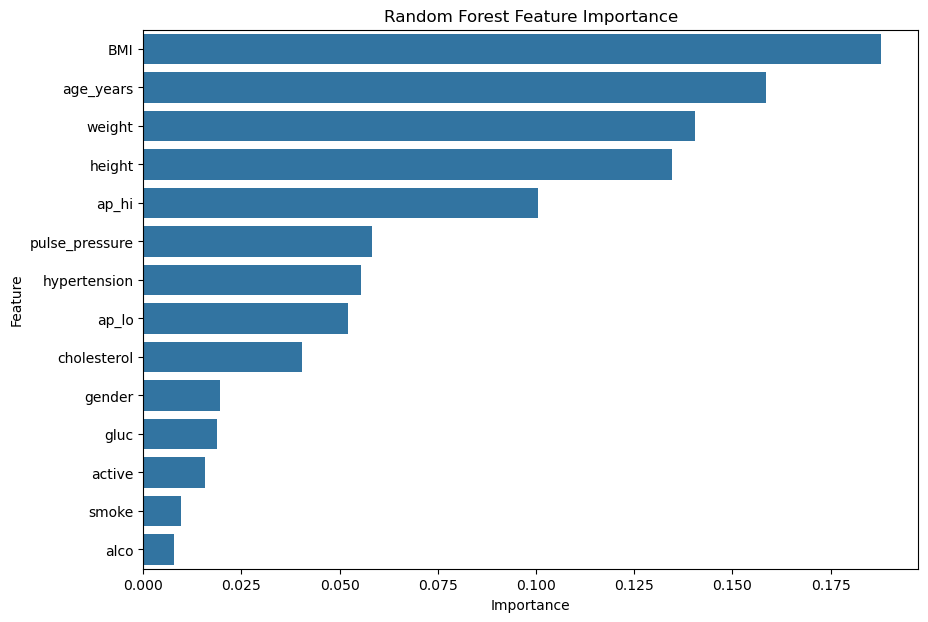

In [39]:
# ============================================================
# EXPERIMENT 2
# RANDOM FOREST CLASSIFIER
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)


# ============================================================
# 1. CREATE RANDOM FOREST MODEL
# ============================================================

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# random_state = reproducible results
# n_jobs=-1    = use all available CPU cores


# ============================================================
# 2. TRAIN RANDOM FOREST
# ============================================================

# IMPORTANT:
# Random Forest does NOT require StandardScaler.

rf.fit(
    X_train,
    y_train
)


# ============================================================
# 3. MAKE PREDICTIONS
# ============================================================

y_pred_rf = rf.predict(
    X_test
)


# Probability of class 1
# Used for ROC-AUC

y_prob_rf = rf.predict_proba(
    X_test
)[:, 1]


# ============================================================
# 4. CALCULATE METRICS
# ============================================================

rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

rf_precision = precision_score(
    y_test,
    y_pred_rf
)

rf_recall = recall_score(
    y_test,
    y_pred_rf
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf
)

rf_auc = roc_auc_score(
    y_test,
    y_prob_rf
)


# ============================================================
# 5. PRINT RESULTS
# ============================================================

print("=" * 60)
print("RANDOM FOREST RESULTS")
print("=" * 60)

print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1 Score  : {rf_f1:.4f}")
print(f"ROC-AUC   : {rf_auc:.4f}")


# ============================================================
# 6. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=[
            "No Cardiovascular Disease",
            "Cardiovascular Disease"
        ]
    )
)


# ============================================================
# 7. CONFUSION MATRIX
# ============================================================

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "No Disease",
        "Disease"
    ],
    yticklabels=[
        "No Disease",
        "Disease"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")

plt.show()


# ============================================================
# 8. ROC CURVE
# ============================================================

fpr_rf, tpr_rf, thresholds_rf = roc_curve(
    y_test,
    y_prob_rf
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest AUC = {rf_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Random Forest - ROC Curve")

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()


# ============================================================
# 9. FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": rf.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)


print("\nFeature Importance:")
print(
    feature_importance.to_string(index=False)
)


# ============================================================
# 10. FEATURE IMPORTANCE GRAPH
# ============================================================

plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title(
    "Random Forest Feature Importance"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [40]:
# ============================================================
# 11. 5-FOLD CROSS VALIDATION
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results_rf = cross_validate(
    rf,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)


print("=" * 60)
print("RANDOM FOREST - 5 FOLD CROSS VALIDATION")
print("=" * 60)

for metric in scoring.keys():

    scores = cv_results_rf[
        "test_" + metric
    ]

    print(
        f"{metric.upper():10s}: "
        f"{scores.mean():.4f} "
        f"+/- {scores.std():.4f}"
    )

RANDOM FOREST - 5 FOLD CROSS VALIDATION
ACCURACY  : 0.7073 +/- 0.0020
PRECISION : 0.7085 +/- 0.0029
RECALL    : 0.6937 +/- 0.0043
F1        : 0.7010 +/- 0.0022
ROC_AUC   : 0.7656 +/- 0.0042


In [41]:
# ============================================================
# RANDOM FOREST - HYPERPARAMETER TUNING
# ============================================================

from sklearn.model_selection import GridSearchCV

# Smaller search space
# We first search a few important values instead of
# trying too many combinations.

param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20],
    "min_samples_split": [2, 5]
}


grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,

    # Use 3-fold CV for faster tuning
    cv=3,

    # ROC-AUC is useful for our binary classification problem
    scoring="roc_auc",

    # Use all available CPU cores
    n_jobs=-1,

    # We don't need training scores right now
    return_train_score=False,

    # Show progress
    verbose=2
)


# Start tuning
grid_rf.fit(X_train, y_train)


print("=" * 60)
print("RANDOM FOREST TUNING")
print("=" * 60)

print("Best Parameters:")
print(grid_rf.best_params_)

print(
    f"Best CV ROC-AUC: "
    f"{grid_rf.best_score_:.4f}"
)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
RANDOM FOREST TUNING
Best Parameters:
{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Best CV ROC-AUC: 0.7988


In [42]:
# ============================================================
# 13. BEST RANDOM FOREST
# ============================================================

best_rf = grid_rf.best_estimator_


y_pred_best_rf = best_rf.predict(
    X_test
)

y_prob_best_rf = best_rf.predict_proba(
    X_test
)[:, 1]


# Metrics

best_rf_accuracy = accuracy_score(
    y_test,
    y_pred_best_rf
)

best_rf_precision = precision_score(
    y_test,
    y_pred_best_rf
)

best_rf_recall = recall_score(
    y_test,
    y_pred_best_rf
)

best_rf_f1 = f1_score(
    y_test,
    y_pred_best_rf
)

best_rf_auc = roc_auc_score(
    y_test,
    y_prob_best_rf
)


print("=" * 60)
print("TUNED RANDOM FOREST")
print("=" * 60)

print(
    f"Accuracy  : {best_rf_accuracy:.4f}"
)

print(
    f"Precision : {best_rf_precision:.4f}"
)

print(
    f"Recall    : {best_rf_recall:.4f}"
)

print(
    f"F1 Score  : {best_rf_f1:.4f}"
)

print(
    f"ROC-AUC   : {best_rf_auc:.4f}"
)

TUNED RANDOM FOREST
Accuracy  : 0.7376
Precision : 0.7707
Recall    : 0.6685
F1 Score  : 0.7160
ROC-AUC   : 0.8048


In [43]:
# ============================================================
# 14. MODEL COMPARISON
# ============================================================

model_comparison = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Tuned Random Forest"
    ],

    "Accuracy": [
        best_accuracy,
        best_rf_accuracy
    ],

    "Precision": [
        best_precision,
        best_rf_precision
    ],

    "Recall": [
        best_recall,
        best_rf_recall
    ],

    "F1 Score": [
        best_f1,
        best_rf_f1
    ],

    "ROC-AUC": [
        best_auc,
        best_rf_auc
    ]

})


print("=" * 70)
print("LOGISTIC REGRESSION VS RANDOM FOREST")
print("=" * 70)

print(
    model_comparison.round(4).to_string(index=False)
)

LOGISTIC REGRESSION VS RANDOM FOREST
              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression    0.7310     0.7678  0.6542    0.7065   0.7991
Tuned Random Forest    0.7376     0.7707  0.6685    0.7160   0.8048


In [44]:
categorical_features = [
    "gender",
    "cholesterol",
    "gluc",
    "smoke",
    "alco",
    "active"
]

for col in categorical_features:
    print(f"\n{col.upper()}")
    print(pd.crosstab(df[col], df["cardio"], normalize="index") * 100)

    # This analysis is very useful because it helps identify which categorical variables are actually associated with cardiovascular disease before training any machine learning model. It also provides clear, evidence-based observations you can include in your project report or presentation.


GENDER
cardio          0          1
gender                      
1       50.789603  49.210397
2       50.039704  49.960296

CHOLESTEROL
cardio               0          1
cholesterol                      
1            56.457285  43.542715
2            40.374274  59.625726
3            23.735062  76.264938

GLUC
cardio          0          1
gluc                        
1       52.441992  47.558008
2       41.145114  58.854886
3       38.224012  61.775988

SMOKE
cardio          0          1
smoke                       
0       50.274778  49.725222
1       53.155541  46.844459

ALCO
cardio          0          1
alco                        
0       50.425574  49.574426
1       52.348443  47.651557

ACTIVE
cardio          0          1
active                      
0       46.728418  53.271582
1       51.458160  48.541840


In [45]:
df.drop(columns=["id"], inplace=True)
df.drop(columns=["age"], inplace=True)
df.drop(columns=["high_cholesterol"], inplace=True)
df.drop(columns=["high_glucose"], inplace=True)
df.drop(columns=["obesity"], inplace=True)

In [46]:
df

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,BMI,pulse_pressure,hypertension
0,2,168,62.0,110,80,1,1,0,0,1,0,50,21.97,30,0
1,1,156,85.0,140,90,3,1,0,0,1,1,55,34.93,50,1
2,1,165,64.0,130,70,3,1,0,0,0,1,51,23.51,60,0
3,2,169,82.0,150,100,1,1,0,0,1,1,48,28.71,50,1
4,1,156,56.0,100,60,1,1,0,0,0,0,47,23.01,40,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,2,168,76.0,120,80,1,1,1,0,1,0,52,26.93,40,0
69996,1,158,126.0,140,90,2,2,0,0,1,1,61,50.47,50,1
69997,2,183,105.0,180,90,3,1,0,1,0,1,52,31.35,90,1
69998,1,163,72.0,135,80,1,2,0,0,0,1,61,27.10,55,0


In [47]:
X = df.drop("cardio", axis=1)
y = df["cardio"]

In [48]:
print(X.shape)
print(y.shape)

(68633, 14)
(68633,)


In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  # It keeps the same proportion of healthy and diseased patients in both the training and test sets, which is important for classification problems.
)

In [50]:
print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(54906, 14)
(13727, 14)
cardio
0    0.505282
1    0.494718
Name: proportion, dtype: float64
cardio
0    0.505282
1    0.494718
Name: proportion, dtype: float64


In [51]:
# why we need scaling ?
# Example with Logistic Regression

# Logistic Regression learns an equation like:

# z=w1x1+w2x2+…+wnxn+b


# What StandardScaler Does

# It transforms every feature to approximately:

# Mean = 0
# Standard Deviation = 1

# ex

# before scaling:
# | Height | Weight | BMI |
# | -----: | -----: | --: |
# |    170 |     70 |  25 |
# |    160 |     60 |  23 |
# |    180 |     80 |  28 |

# after scaling:
# | Height | Weight |   BMI |
# | -----: | -----: | ----: |
# |   0.35 |   0.21 |  0.18 |
# |  -1.12 |  -1.01 | -0.76 |
# |   1.45 |   1.31 |  1.42 |

# Now all features are on a comparable scale.

# z=(x−μ)/σ


In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [53]:
# 1.Linear Regression

# Student Marks

# ↓

# 82.5

# Predicts a number.


# 2.Logistic Regression

# Student

# ↓

# Probability of Passing = 0.92

# ↓

# Pass

# It predicts the probability of belonging to a class and then converts that probability into a class label

# Thats The Whole Point logistic Regression Is Just Name But Its For Classification Basically Binary Classification  

In [54]:
from sklearn.linear_model import LogisticRegression

In [55]:
lr = LogisticRegression(random_state=42) 

# rando_state : random_state is simply a seed for the random number generator.

# It ensures that every time you run your code, you get the same random result.

In [56]:
lr.fit(X_train_scaled, y_train)  #Logistic Regression → use scaled data
#Training Is Done

LogisticRegression(random_state=42)

In [57]:
y_pred = lr.predict(X_test_scaled)

In [58]:
print(y_pred[:10])

[0 0 1 1 0 0 0 0 0 1]


In [59]:
# Predict Probabilities

# Instead of just 0 or 1, Logistic Regression can tell us the probability.

y_prob = lr.predict_proba(X_test_scaled)
print(y_prob[:5])

[[0.76727492 0.23272508]
 [0.90527381 0.09472619]
 [0.17112759 0.82887241]
 [0.13236458 0.86763542]
 [0.68959881 0.31040119]]


In [60]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.7306039192831646


In [61]:
lr.intercept_

array([0.03706572])

In [62]:
lr.coef_  # coefficients of the features in the decision function

array([[ 0.00037463,  0.01710148,  0.0901333 ,  0.30656178,  0.1877752 ,
         0.32704625, -0.07032005, -0.05096235, -0.05191515, -0.09385798,
         0.35056297,  0.0637981 ,  0.28644563,  0.36545344]])

In [63]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)  # confusion matrix is a table that is often used to describe the performance of a classification model (or "classifier") on a set of test data for which the true values are known. It allows the visualization of the performance of an algorithm

print(cm)

[[5578 1358]
 [2340 4451]]


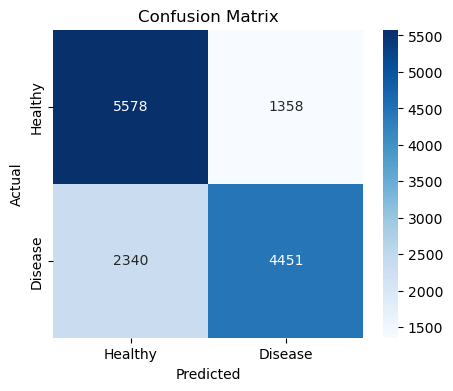

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Healthy","Disease"],
    yticklabels=["Healthy","Disease"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [65]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.70      0.80      0.75      6936
           1       0.77      0.66      0.71      6791

    accuracy                           0.73     13727
   macro avg       0.74      0.73      0.73     13727
weighted avg       0.74      0.73      0.73     13727



In [66]:
from sklearn.metrics import roc_auc_score

y_prob = lr.predict_proba(X_test_scaled)[:, 1]

auc = roc_auc_score(y_test, y_prob)  # ROC-AUC tells you how well the model separates healthy and diseased patients overall.

print("ROC-AUC :", auc)

ROC-AUC : 0.7984435647152917


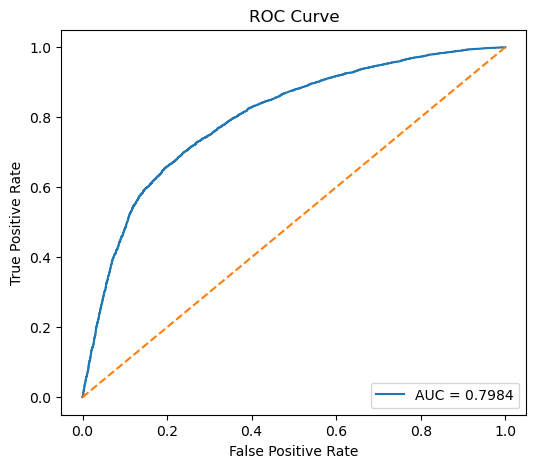

In [67]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")

plt.show()

In [68]:
import numpy as np
from sklearn.metrics import accuracy_score


# STEP 1: ADD BIAS COLUMN

# Logistic Regression equation:
#
# z = θ0 + θ1*x1 + θ2*x2 + ... + θn*xn
#
# θ0 is the bias/intercept.
#
# We add a column of 1's so that θ0 can also be handled
# through matrix multiplication.

X_train_bias = np.c_[
    np.ones(X_train.shape[0]),   # Add 1 for every training row
    X_train                      # Original training features
].astype(np.float64)


# Convert target values into NumPy array
# and make sure they are floating point numbers.
#
# Example:
# Y_train = [0, 1, 0, 1, ...]

y_train = np.array(y_train, dtype=np.float64)


# STEP 2: INITIALIZE THETA (WEIGHTS)

# Number of columns in X_train_bias =
# number of features + 1 bias column.
#
# Initially, we don't know the best weights.
# So we start every θ with 0.
#
# Example:
# If there are 14 features:
#
# theta = [0, 0, 0, ..., 0]
#          ↑
#         θ0
#
# There will be 15 values.

theta = np.zeros(X_train_bias.shape[1])


# STEP 3: SIGMOID FUNCTION

def sigmoid(z):

    # Sigmoid converts any number into a value between 0 and 1.
    #
    # Example:
    #
    # z = 0     → 0.50
    # z = 2     → 0.88
    # z = -2    → 0.12
    #
    # This allows Logistic Regression to produce
    # probabilities.

    return 1 / (1 + np.exp(-z))


# STEP 4: COST FUNCTION

def compute_cost(X, y, theta):

    # Number of training examples
    m = len(y)

    # Calculate z:
    #
    # z = Xθ
    #
    # This gives the raw prediction score.

    z = X @ theta

    # Convert raw score into probability
    h = sigmoid(z)

    # Logistic Regression uses Binary Cross Entropy
    # (also called Log Loss).
    #
    # This tells us how wrong our predictions are.
    #
    # Lower cost = better model.

    cost = -(1 / m) * np.sum(
        y * np.log(h) +
        (1 - y) * np.log(1 - h)
    )

    return cost


# STEP 5: GRADIENT DESCENT

def gradient_descent(X, y, theta, alpha, iterations):

    # Number of training examples
    m = len(y)

    # We will store the cost after every iteration.
    #
    # This is useful later to check whether
    # Gradient Descent is actually reducing the cost.

    cost_history = []


    # Repeat the process many times
    for i in range(iterations):


        # STEP 5.1: CALCULATE CURRENT PREDICTIONS

        # Calculate:
        #
        # z = Xθ

        z = X @ theta


        # Convert z into probabilities using sigmoid

        h = sigmoid(z)


        # STEP 5.2: CALCULATE GRADIENT

        # Gradient tells us:
        #
        # "In which direction should each θ move
        #  to reduce the cost?"
        #
        # Formula:
        #
        # gradient = (1/m) Xᵀ(h - y)

        gradient = (1 / m) * (X.T @ (h - y))


        # STEP 5.3: UPDATE THETA

        # Gradient Descent formula:
        #
        # θ = θ - α × gradient
        #
        # alpha = learning rate
        #
        # We subtract because we want to move
        # towards LOWER cost.

        theta = theta - alpha * gradient


        # STEP 5.4: CALCULATE NEW COST

        # After updating theta, calculate the new cost.

        cost = compute_cost(X, y, theta)


        # Store the cost

        cost_history.append(cost)


    # Return the final weights
    # and the complete cost history.

    return theta, cost_history


# STEP 6: TRAIN OUR MANUAL MODEL

# alpha = learning rate
# iterations = number of times Gradient Descent runs

theta_final, cost_history = gradient_descent(
    X_train_bias,
    y_train,
    theta,
    alpha=0.01,
    iterations=1000
)


# Display the final learned weights

print("Final θ values:")
print(theta_final)


# Display the final cost

print("Final Cost:")
print(cost_history[-1])


# STEP 7: PREPARE TEST DATA

# Test data also needs the bias column.
#
# IMPORTANT:
# We are NOT training again on the test data.
# We are only adding the same bias column.

X_test_bias = np.c_[
    np.ones(X_test.shape[0]),
    X_test
].astype(np.float64)


# STEP 8: MAKE PREDICTIONS

# First calculate the raw score:
#
# z = X_test × θ

z_test = X_test_bias @ theta_final


# Convert raw score into probability

y_pred_prob = sigmoid(z_test)


# STEP 9: CONVERT PROBABILITY INTO CLASS

# If probability >= 0.5:
#       class = 1
#
# Otherwise:
#       class = 0
#
# Example:
#
# 0.82 → 1
# 0.71 → 1
# 0.43 → 0
# 0.12 → 0

y_pred_manual = (y_pred_prob >= 0.5).astype(int)


# STEP 10: CHECK ACCURACY

accuracy = accuracy_score(
    y_test,
    y_pred_manual
)

print("Manual Gradient Descent Accuracy:", accuracy)

C:\Users\shiho\AppData\Local\Temp\ipykernel_35176\864447271.py:96: RuntimeWarning: divide by zero encountered in log
  (1 - y) * np.log(1 - h)
C:\Users\shiho\AppData\Local\Temp\ipykernel_35176\864447271.py:96: RuntimeWarning: invalid value encountered in multiply
  (1 - y) * np.log(1 - h)


Final θ values:
[-0.05579164  0.02492509 -5.65718602  1.77243525  3.26831362  1.37077631
  0.45899659  0.08509123 -0.00798027 -0.01293694 -0.11474147  1.59302032
 -0.57273978  1.89753731  0.49348263]
Final Cost:
nan
Manual Gradient Descent Accuracy: 0.5937932541706127


In [71]:
import joblib
# from google.colab import files

# # Choose your final model
final_model = best_rf

# # Save model
joblib.dump(final_model, "frontend/cardiovascular_model.pkl")

print("Model saved successfully!")

# files.download("/content/cardiovascular_model.pkl")

Model saved successfully!
